Здесь будем строить ЭФР и гистрограммы для данных из дескриптора. 
При построении будем делить данные на различные классы, чтобы проанализировать распределения в зависимости от различных классов. В этой работе я решил проанализировать такие группировки:
1. Рынок (первичка, вторичка)
1. Тип квартиры (квартира, студия)
2. Гео. Для выполнения этой группировки я разбил все точки на 6 классов по терриореальному расположению. Классы выбраны рандомные, без какого-либо обсонования. Визуализация расположения расположения расположена в ячейке `[7]`.

Для начала я решил построить ЭФР для двух столбцов - площадь (area), этаж квартиры (floor).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
#df_clusters = pd.read_parquet("../data/geocoding/geocodes_checkpoint.parquet", engine='fastparquet')

#print(df_clusters["latitude"].isna().mean() * 100, "%")

# Получил 77 процентов пропусков, поэтому геокодирование пока опустим

In [3]:
import os
path = "../data/processed/v2/housing_residential_processed.parquet"
print("Файл существует:", os.path.exists(path))
if os.path.exists(path):
    print("Размер файла:", os.path.getsize(path), "байт")
    # Если размер очень мал (например, < 100 байт), файл почти наверняка битый.

Файл существует: True
Размер файла: 31144832 байт


In [4]:
df = pd.read_parquet("../data/processed/v2/housing_residential_processed.parquet")
data = df.copy()

print(df.columns)
print(f"Всего записей: {len(df)}")

df_clean = df.dropna(subset=["longitude", "latitude"]).copy()

Index(['address', 'longitude', 'latitude', 'area', 'room_count', 'floor',
       'floor_count', 'market_type', 'flat_type', 'ceiling_height',
       'build_year', 'balcony', 'price', 'price_per_square_meter', 'date'],
      dtype='str')
Всего записей: 1336403


In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

n_clusters = 6          # количество класстеров
random_state = 42

geo_df = df_clean.dropna(subset=["longitude", "latitude"]).copy()

coords = geo_df[["longitude", "latitude"]].values

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=random_state,
    n_init="auto"
)

cluster_labels = kmeans.fit_predict(coords_scaled)

geo_df["cluster_zone"] = cluster_labels

df_clean.loc[geo_df.index, "cluster_zone"] = cluster_labels

clusters = sorted(geo_df["cluster_zone"].unique())
cmap = plt.get_cmap("tab10")
cluster_colors = {cl: cmap(i % 10) for i, cl in enumerate(clusters)}

print(df_clean["cluster_zone"].value_counts(dropna=False).sort_index())

cluster_zone
0.0    216305
1.0    219497
2.0    233735
3.0    308444
4.0    190487
5.0    167935
Name: count, dtype: int64


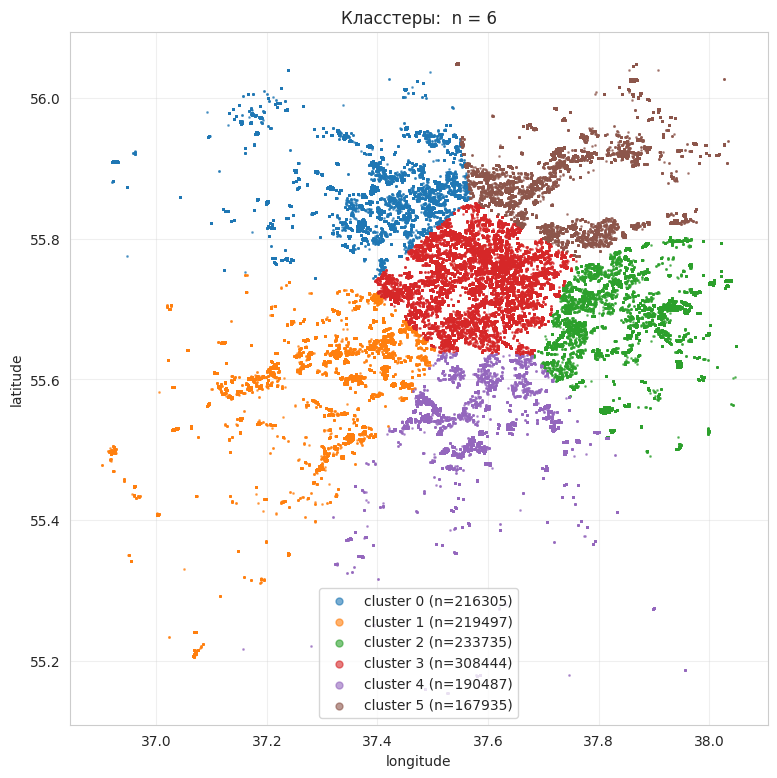

In [19]:
point_size = 1
point_alpha = 0.6

centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

clusters = sorted(geo_df["cluster_zone"].unique())
cmap = plt.get_cmap("tab10")
cluster_colors = {cl: cmap(i % 10) for i, cl in enumerate(clusters)}

fig, ax = plt.subplots(figsize=(9, 9))

for cl in clusters:
    subset = geo_df[geo_df["cluster_zone"] == cl]
    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        s=point_size,
        alpha=point_alpha,
        color=cluster_colors[cl],
        label=f"cluster {cl} (n={len(subset)})"
    )

ax.set_title(f"Класстеры:  n = {n_clusters}")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="best", markerscale=5)
ax.grid(alpha=0.3)
plt.show()

In [7]:
# Создаём столбец и заполняем его значением по умолчанию
df["cluster_zone"] = -1

# Заполняем метками для тех строк, которые были в df_clean
df.loc[df_clean.index, "cluster_zone"] = df_clean["cluster_zone"]

# Проверяем, сколько объектов осталось без кластера
print(
    f"Объектов без кластера (из‑за пропусков координат): {(df['cluster_zone'] == -1).sum()}"
)

if "cluster_zone" not in df.columns:
    df_clean = df.dropna(subset=["longitude", "latitude"]).copy()
    coords = df_clean[["longitude", "latitude"]].values
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

    kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
    clusters = kmeans.fit_predict(coords_scaled)
    df_clean["cluster_zone"] = clusters

    df["cluster_zone"] = -1
    df.loc[df_clean.index, "cluster_zone"] = df_clean["cluster_zone"]

Объектов без кластера (из‑за пропусков координат): 0


In [8]:
def compare_primary_secondary(primary_df, secondary_df, min_samples=10):
    area_prim = primary_df["area"].dropna()
    area_sec = secondary_df["area"].dropna()
    floor_prim = primary_df["floor"].dropna()
    floor_sec = secondary_df["floor"].dropna()

    n_area_prim = len(area_prim)
    n_area_sec = len(area_sec)
    n_floor_prim = len(floor_prim)
    n_floor_sec = len(floor_sec)

    if (n_area_prim < min_samples and n_area_sec < min_samples) and (
        n_floor_prim < min_samples and n_floor_sec < min_samples
    ):
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Наложение первички и вторички", fontsize=16)

    # ------------------ Гистограмма площади (area) ------------------
    ax = axes[0, 0]
    ax.set_title("Гистограмма площади (area)")
    ax.set_xlabel("Площадь, м²")
    ax.set_ylabel("Плотность")
    if n_area_prim >= min_samples:
        sns.histplot(
            area_prim,
            kde=True,
            stat="density",
            bins=30,
            color="blue",
            alpha=0.5,
            label=f"primary (n={n_area_prim})",
            ax=ax,
        )
    if n_area_sec >= min_samples:
        sns.histplot(
            area_sec,
            kde=True,
            stat="density",
            bins=30,
            color="orange",
            alpha=0.5,
            label=f"secondary (n={n_area_sec})",
            ax=ax,
        )
    if n_area_prim < min_samples and n_area_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ ЭФР площади ------------------
    ax = axes[0, 1]
    ax.set_title("ЭФР площади")
    ax.set_xlabel("Площадь, м²")
    ax.set_ylabel("Доля")
    if n_area_prim >= min_samples:
        sorted_vals = np.sort(area_prim)
        y = np.arange(1, n_area_prim + 1) / n_area_prim
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="blue",
            label=f"primary (n={n_area_prim})",
        )
    if n_area_sec >= min_samples:
        sorted_vals = np.sort(area_sec)
        y = np.arange(1, n_area_sec + 1) / n_area_sec
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="orange",
            label=f"secondary (n={n_area_sec})",
        )
    if n_area_prim < min_samples and n_area_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ Гистограмма этажа (floor) ------------------
    ax = axes[1, 0]
    ax.set_title("Гистрограмма этажа (floor)")
    ax.set_xlabel("Этаж")
    ax.set_ylabel("Плотность")
    if n_floor_prim >= min_samples:
        sns.histplot(
            floor_prim,
            kde=True,
            stat="density",
            bins=30,
            color="blue",
            alpha=0.5,
            label=f"primary (n={n_floor_prim})",
            ax=ax,
        )
    if n_floor_sec >= min_samples:
        sns.histplot(
            floor_sec,
            kde=True,
            stat="density",
            bins=30,
            color="orange",
            alpha=0.5,
            label=f"secondary (n={n_floor_sec})",
            ax=ax,
        )
    if n_floor_prim < min_samples and n_floor_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    # ------------------ ЭФР этажа ------------------
    ax = axes[1, 1]
    ax.set_title("ЭФР этажа")
    ax.set_xlabel("Этаж")
    ax.set_ylabel("Доля")
    if n_floor_prim >= min_samples:
        sorted_vals = np.sort(floor_prim)
        y = np.arange(1, n_floor_prim + 1) / n_floor_prim
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="blue",
            label=f"primary (n={n_floor_prim})",
        )
    if n_floor_sec >= min_samples:
        sorted_vals = np.sort(floor_sec)
        y = np.arange(1, n_floor_sec + 1) / n_floor_sec
        ax.step(
            sorted_vals,
            y,
            where="post",
            color="orange",
            label=f"secondary (n={n_floor_sec})",
        )
    if n_floor_prim < min_samples and n_floor_sec < min_samples:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.legend()

    plt.tight_layout()
    plt.show()

Графики ЭФР для первички и вторички с наложением:

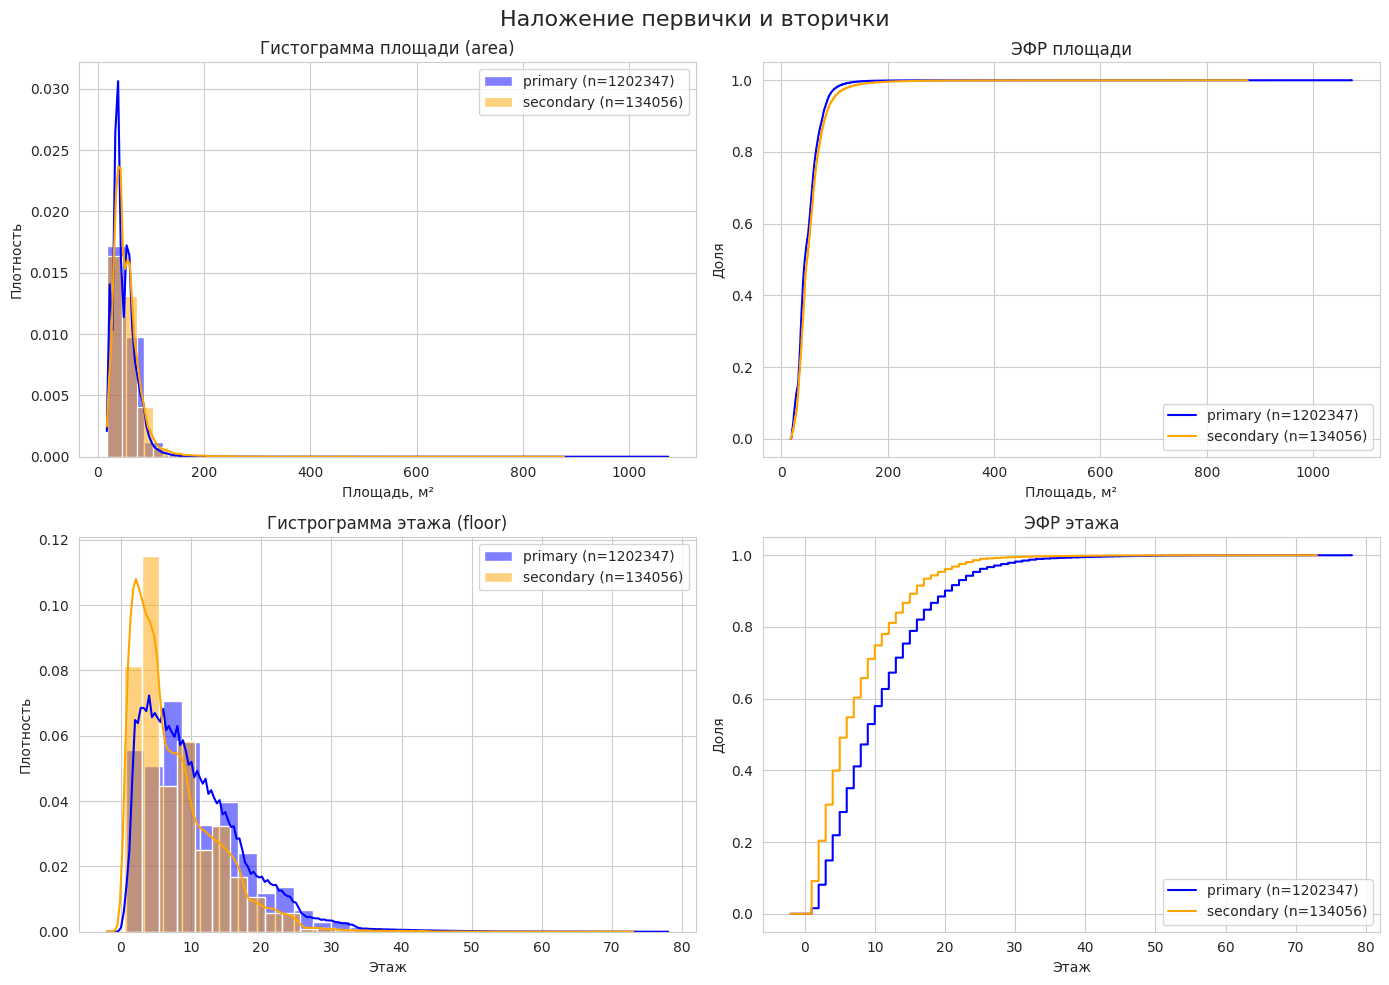

In [9]:
primary = df[df["market_type"] == "primary"]
secondary = df[df["market_type"] == "secondary"]
compare_primary_secondary(primary, secondary)

Построим ЭФР для нужных значений.

In [10]:
def plot_group_distribution(
    group_data, group_name, columns, min_samples=10, log_columns=None, bins=30
):
    """
    Parameters
    ----------
    group_data : DataFrame - Данные группы
    group_name : str - Название группы
    columns : list of str - Список, для чего строить ЭФР и плотности
    min_samples : int, default=10 - Минимальное количество не пропущенных значений
    log_columns : list of str, optional - Колонки, для которых использовать логарифмическую шкалу
    bins : int, default=30 - Количество бинов гистограммы (для логарифмической шкалы бины строятся в лог-пространстве)
    """
    if log_columns is None:
        log_columns = []

    n_params = len(columns)
    if n_params == 0:
        print("Нет параметров для построения")
        return

    fig, axes = plt.subplots(n_params, 2, figsize=(12, 4 * n_params))
    fig.suptitle(f"Группа: {group_name}", fontsize=14)

    # Если всего один параметр, axes будет одномерным, приводим к двумерному виду
    if n_params == 1:
        axes = axes.reshape(1, -1)

    for i, col in enumerate(columns):
        vals = group_data[col].dropna()
        n_vals = len(vals)
        use_log = col in log_columns

        # --- Гистограмма ---
        ax_hist = axes[i, 0]
        if n_vals >= min_samples:
            if use_log:
                # Логарифмические бины
                logbins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), bins)
                sns.histplot(vals, bins=logbins, kde=False, ax=ax_hist, stat="density")
                ax_hist.set_xscale("log")
                title_suffix = " [log]"
            else:
                sns.histplot(vals, kde=True, ax=ax_hist, stat="density", bins=bins)
                title_suffix = ""
            ax_hist.set_title(f"{col} (n={n_vals}){title_suffix}")
            ax_hist.set_xlabel(col)
        else:
            ax_hist.text(0.5, 0.5, "No data", ha="center", va="center")
            ax_hist.set_title(col)

        # --- ЭФР ---
        ax_ecdf = axes[i, 1]
        if n_vals >= min_samples:
            sorted_vals = np.sort(vals)
            y = np.arange(1, n_vals + 1) / n_vals
            ax_ecdf.step(sorted_vals, y, where="post")
            if use_log:
                ax_ecdf.set_xscale("log")
                title_suffix = " [log]"
            else:
                title_suffix = ""
            ax_ecdf.set_title(f"ЭФР {col} (n={n_vals}){title_suffix}")
            ax_ecdf.set_xlabel(col)
            ax_ecdf.set_ylabel("Доля")
        else:
            ax_ecdf.text(0.5, 0.5, "No data", ha="center", va="center")
            ax_ecdf.set_title(f"ЭФР {col}")

    plt.tight_layout()
    plt.show()

Параметры, по которым будем проводить группировки:

In [11]:
groupings = {
    # "overall": None,
    "by_market_type": "market_type",
    "by_flat_type": "flat_type",
    "by_zone": "cluster_zone",
}

Столбцы, для которых надо построить ЭФР указываются в ячейке ниже в массиве `efr_columns=`. 

На момент создания: `efr_columns = ['floor', 'area', 'price']`.

P.S.: для столбцов, для которых нужна лог.шкала не будет построена плотность, лишь гистограмма. Так как `kde=True` не работает корректно с лог.шкалами.

Группировка: by_market_type


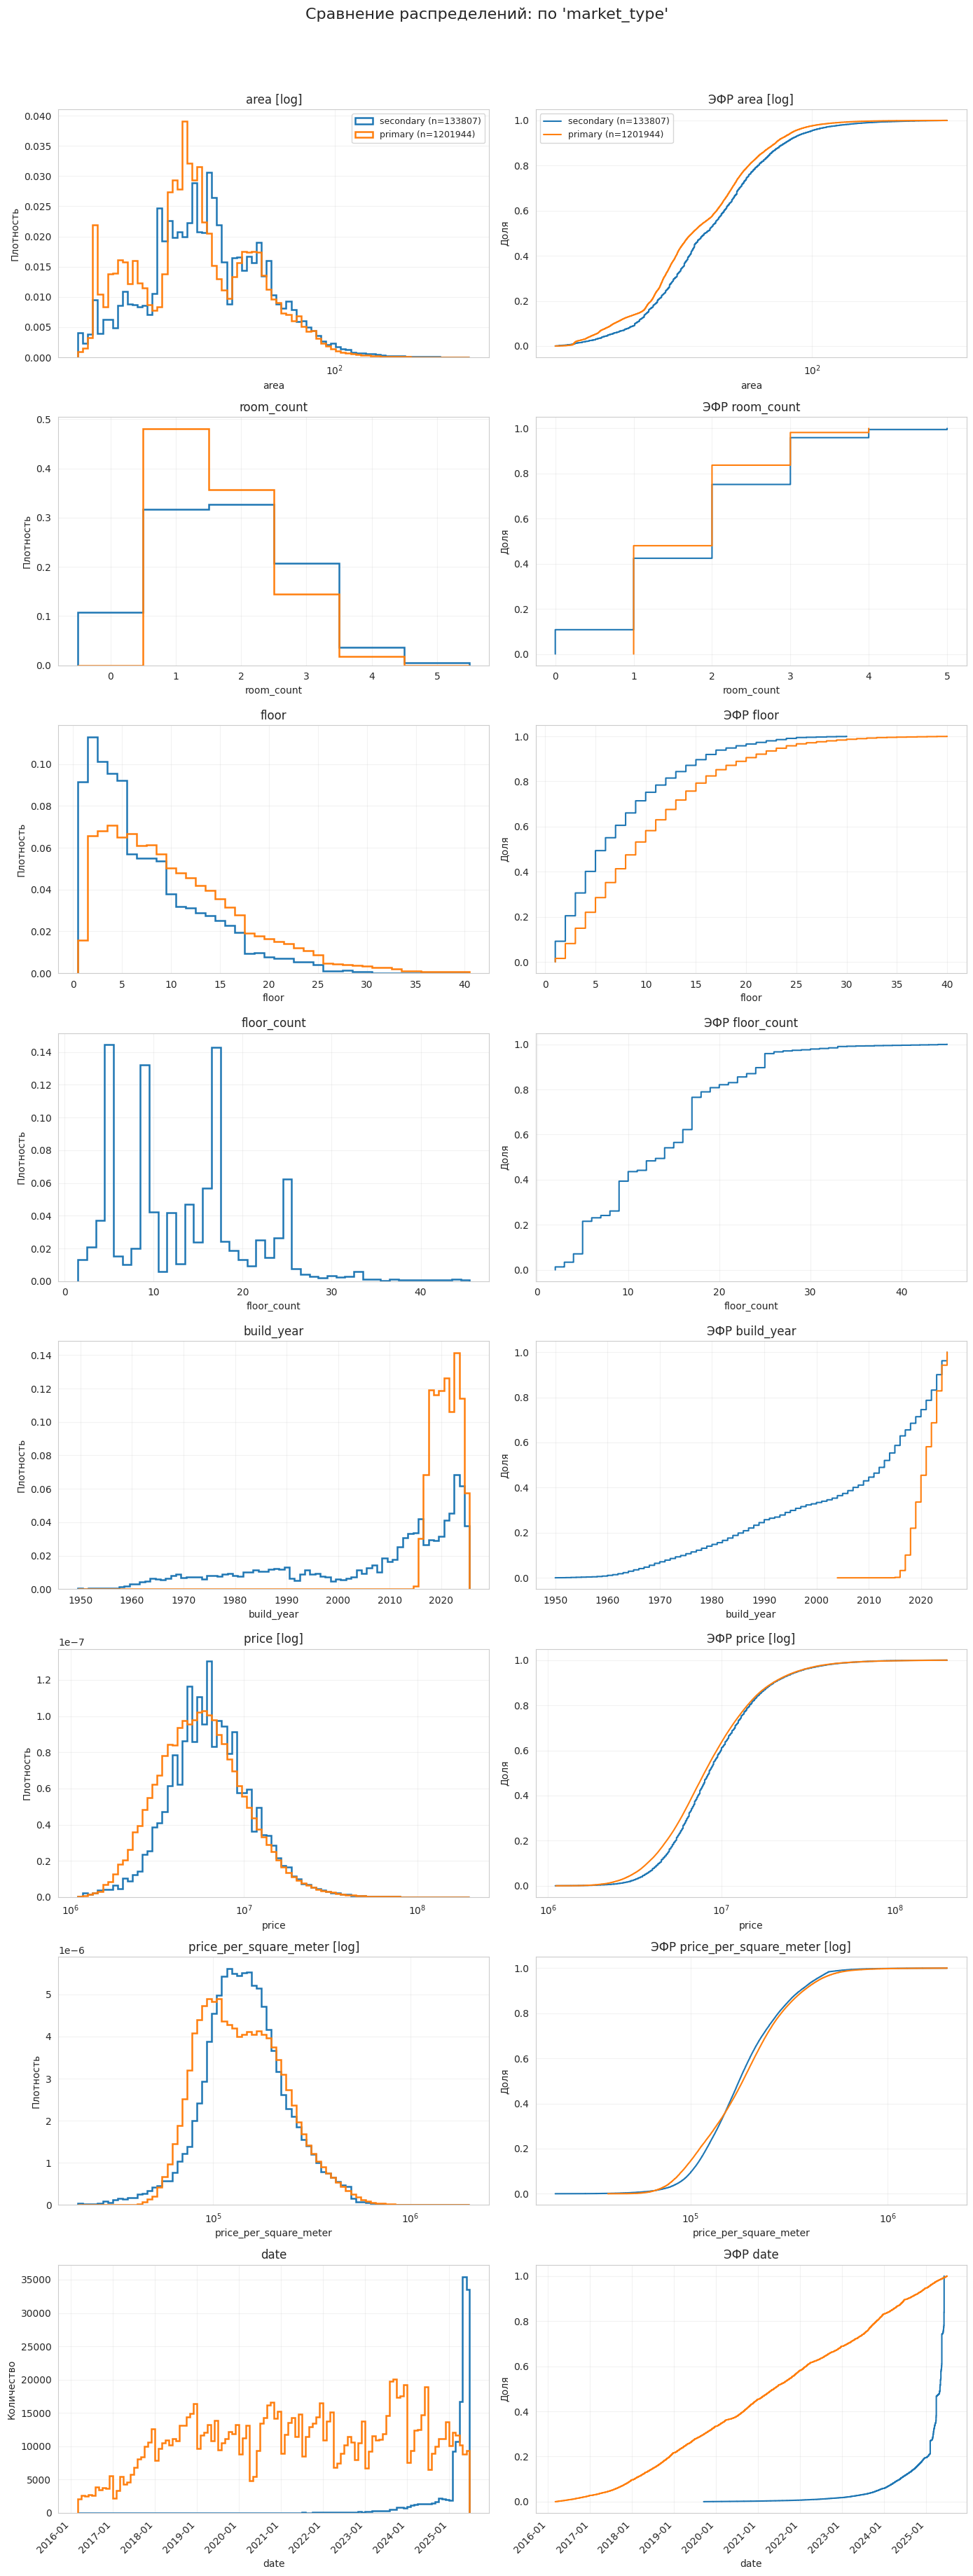

Группировка: by_flat_type


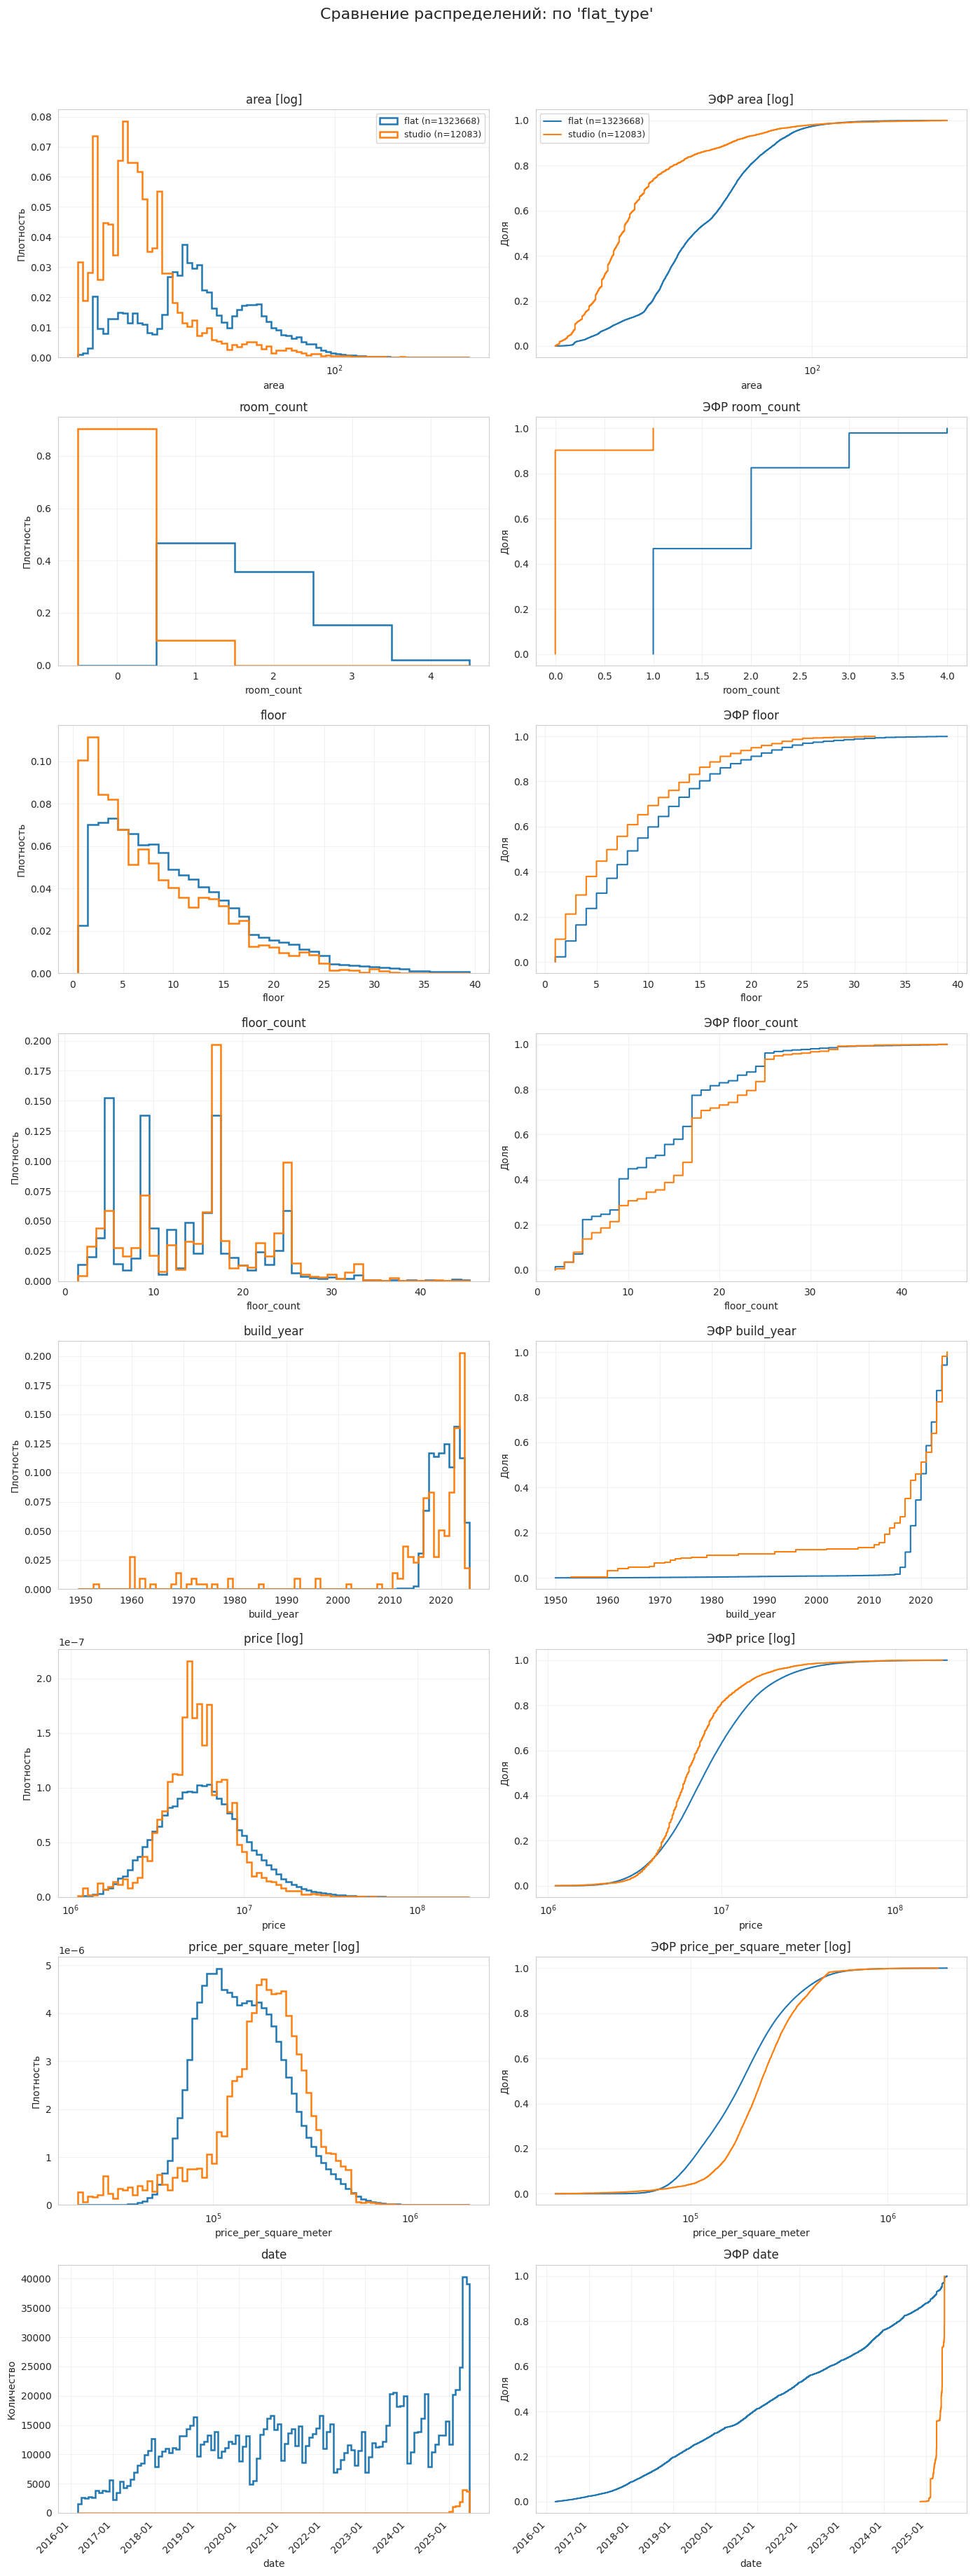

Группировка: by_zone


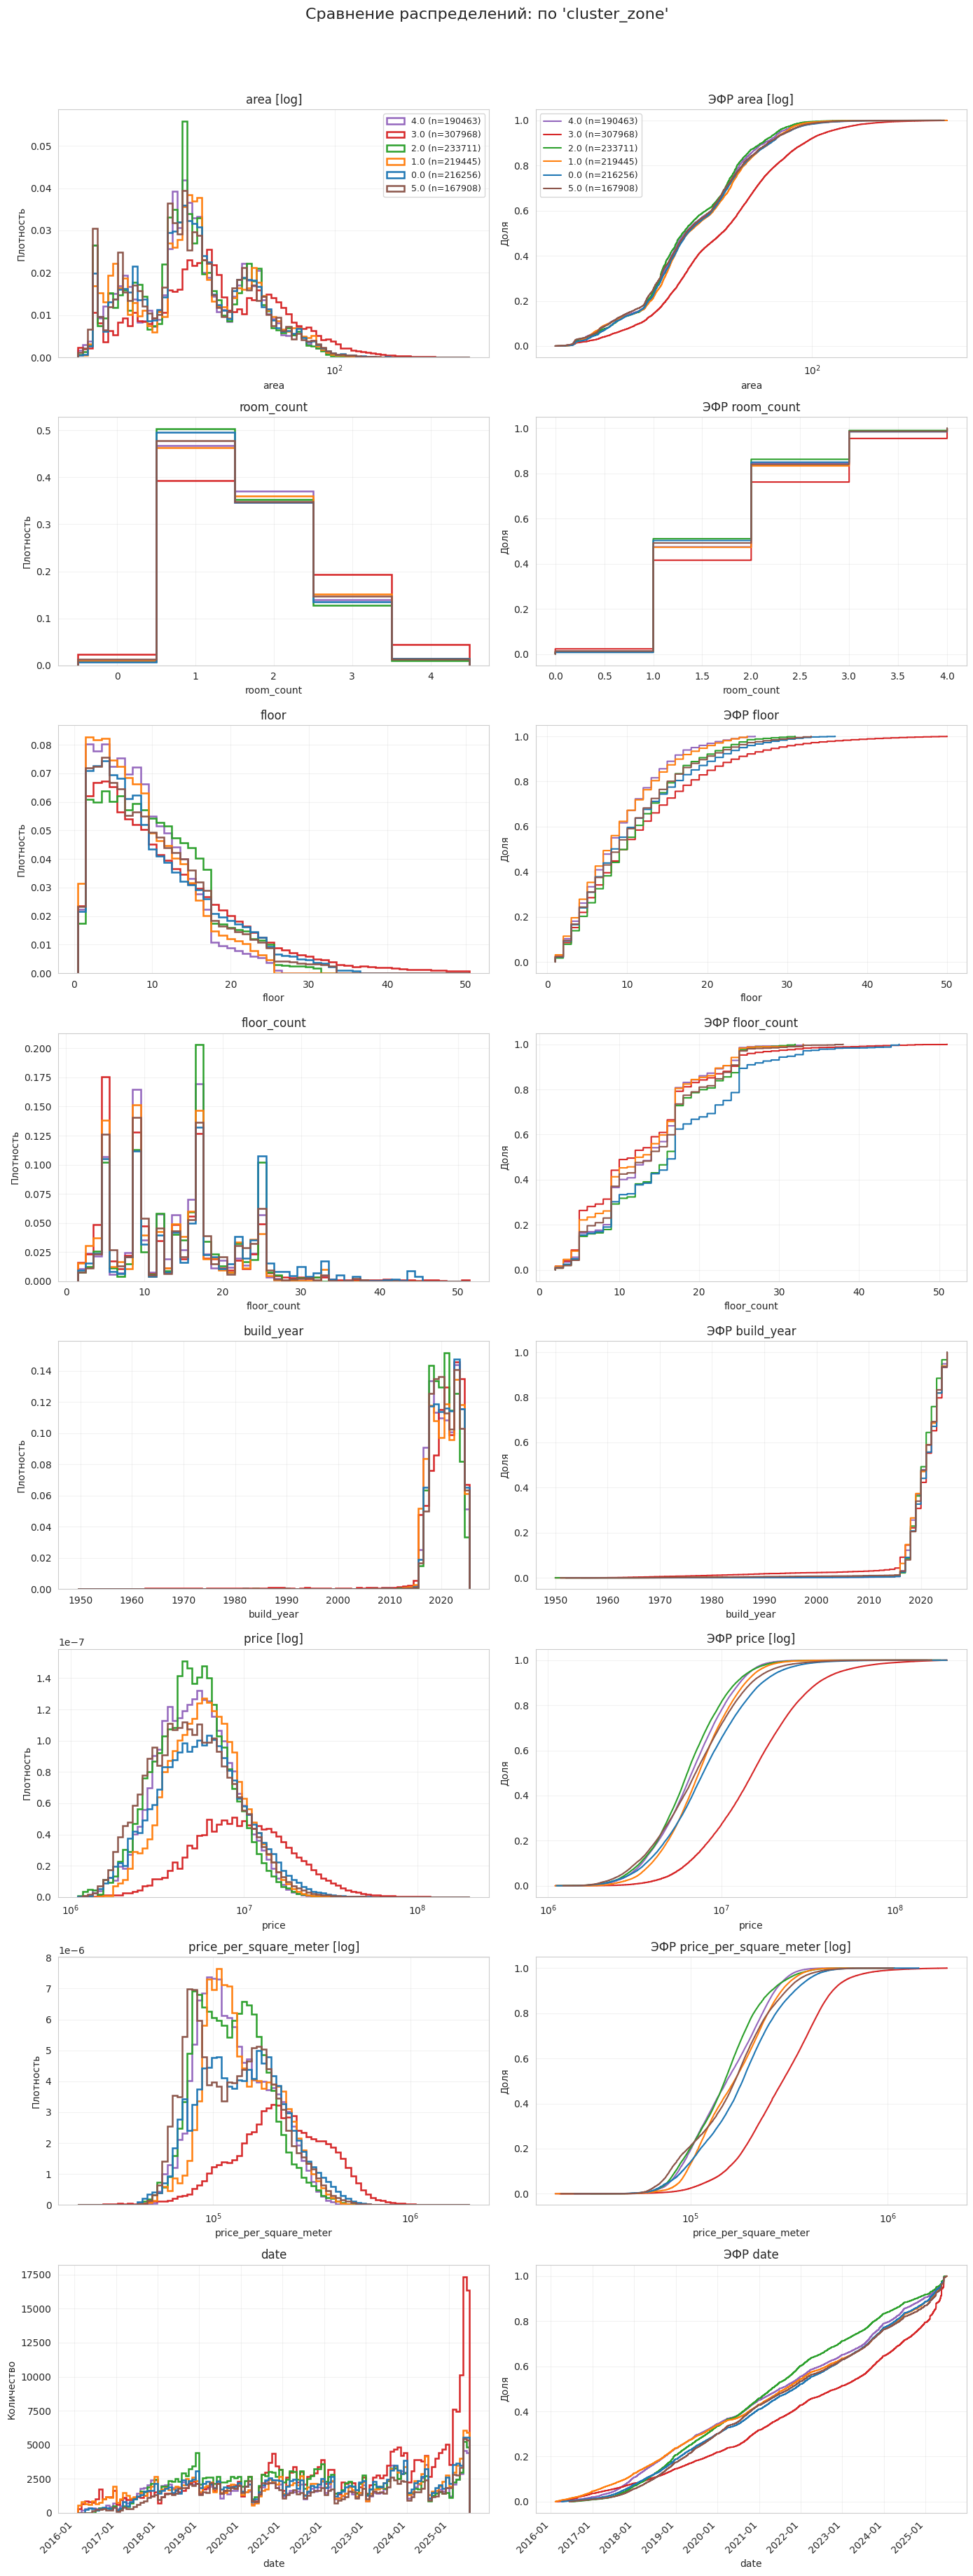

In [20]:
efr_columns = [
    'area', 'room_count', 'floor',
    'floor_count', 'build_year', 'price',
    'price_per_square_meter', 'date'
]

log_columns = ['area', 'price', 'price_per_square_meter']
discrete_columns = ['room_count', 'floor', 'floor_count', 'build_year']
date_columns = ['date']


def _freedman_diaconis_bins(x, min_bins=10, max_bins=80):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n < 2:
        return min_bins

    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1

    if iqr == 0:
        uniq = x.nunique()
        return int(np.clip(uniq, min_bins, max_bins))

    bw = 2 * iqr / (n ** (1 / 3))
    if bw <= 0:
        return min_bins

    bins = int(np.ceil((x.max() - x.min()) / bw))
    return int(np.clip(bins, min_bins, max_bins))


def _prepare_numeric_series(s, use_log=False, clip_q=(0.5, 99.5), xlim=None):
    s = pd.to_numeric(s, errors='coerce').dropna()

    if use_log:
        s = s[s > 0]

    if len(s) == 0:
        return s, None

    if xlim is not None:
        low, high = xlim
    else:
        low, high = np.percentile(s, clip_q)

    s_plot = s[(s >= low) & (s <= high)]
    return s_plot, (low, high)


def _prepare_datetime_series(s, clip_q=(0.5, 99.5), xlim=None):
    s = pd.to_datetime(s, errors='coerce').dropna()

    if len(s) == 0:
        return s, None

    if xlim is not None:
        low, high = pd.to_datetime(xlim[0]), pd.to_datetime(xlim[1])
    else:
        low = s.quantile(clip_q[0] / 100)
        high = s.quantile(clip_q[1] / 100)

    s_plot = s[(s >= low) & (s <= high)]
    return s_plot, (low, high)


def plot_group_comparison(
    df,
    group_col,
    columns,
    log_columns=None,
    discrete_columns=None,
    date_columns=None,
    min_samples=10,
    percentile_clip=(0.5, 99.5),
    plot_kwargs=None,
    group_colors=None,
):
    if log_columns is None:
        log_columns = []
    if discrete_columns is None:
        discrete_columns = []
    if date_columns is None:
        date_columns = []
    if plot_kwargs is None:
        plot_kwargs = {}

    if group_col is None:
        groups = [('all', df)]
    else:
        groups = []
        for val in df[group_col].dropna().unique():
            grp = df[df[group_col] == val]
            groups.append((val, grp))

    n_params = len(columns)
    if n_params == 0:
        print("Нет параметров для построения")
        return

    fig, axes = plt.subplots(n_params, 2, figsize=(14, 4.5 * n_params))
    if n_params == 1:
        axes = axes.reshape(1, -1)


    for i, col in enumerate(columns):
        use_log = col in log_columns
        is_discrete = col in discrete_columns
        is_date = col in date_columns

        ax_hist = axes[i, 0]
        ax_ecdf = axes[i, 1]

        col_kwargs = plot_kwargs.get(col, {})
        custom_xlim = col_kwargs.get("xlim", None)

        all_vals = []
        for _, grp in groups:
            if is_date:
                vals, _ = _prepare_datetime_series(
                    grp[col],
                    clip_q=percentile_clip,
                    xlim=custom_xlim
                )
            else:
                vals, _ = _prepare_numeric_series(
                    grp[col],
                    use_log=use_log,
                    clip_q=percentile_clip,
                    xlim=custom_xlim
                )

            if len(vals) >= min_samples:
                all_vals.append(vals)

        if len(all_vals) == 0:
            ax_hist.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_ecdf.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_hist.set_title(col)
            ax_ecdf.set_title(f"ЭФР {col}")
            continue

        if is_date:
            all_vals_concat = pd.concat([pd.Series(v) for v in all_vals], ignore_index=True)
            global_low = all_vals_concat.min()
            global_high = all_vals_concat.max()

            hist_bins = pd.date_range(
                global_low.to_period("M").start_time,
                global_high.to_period("M").end_time,
                freq="MS"
            )

            if len(hist_bins) < 2:
                hist_bins = pd.date_range(
                    global_low.floor("D"),
                    global_high.ceil("D"),
                    periods=10
                )

        elif is_discrete:
            all_vals_concat = pd.concat([pd.Series(v) for v in all_vals], ignore_index=True).astype(float)
            global_low = int(np.floor(all_vals_concat.min()))
            global_high = int(np.ceil(all_vals_concat.max()))
            hist_bins = np.arange(global_low - 0.5, global_high + 1.5, 1)

        elif use_log:
            all_vals_concat = pd.concat([pd.Series(v) for v in all_vals], ignore_index=True).astype(float)
            global_low = all_vals_concat.min()
            global_high = all_vals_concat.max()

            if global_low <= 0 or global_low == global_high:
                hist_bins = 20
            else:
                n_bins = _freedman_diaconis_bins(np.log10(all_vals_concat))
                hist_bins = np.logspace(np.log10(global_low), np.log10(global_high), n_bins)

        else:
            all_vals_concat = pd.concat([pd.Series(v) for v in all_vals], ignore_index=True).astype(float)
            hist_bins = _freedman_diaconis_bins(all_vals_concat)



        for (label, grp) in groups:
            if group_colors is not None and label in group_colors:
                color = group_colors[label]
            else:
                color = None

            if is_date:
                vals, xlim = _prepare_datetime_series(
                    grp[col],
                    clip_q=percentile_clip,
                    xlim=custom_xlim
                )
            else:
                vals, xlim = _prepare_numeric_series(
                    grp[col],
                    use_log=use_log,
                    clip_q=percentile_clip,
                    xlim=custom_xlim
                )

            n_vals = len(vals)
            if n_vals < min_samples:
                continue

            if is_date:
                ax_hist.hist(
                    vals,
                    bins=hist_bins,
                    density=False,
                    histtype='step',
                    linewidth=1.8,
                    color=color,
                    label=f"{label} (n={n_vals})"
                )
            else:
                ax_hist.hist(
                    vals,
                    bins=hist_bins,
                    density=True,
                    histtype='step',
                    linewidth=1.8,
                    color=color,
                    label=f"{label} (n={n_vals})"
                )

            vals_sorted = pd.Series(vals).sort_values()
            y = np.arange(1, n_vals + 1) / n_vals
            ax_ecdf.step(
                vals_sorted,
                y,
                where='post',
                color=color,
                linewidth=1.5,
                label=f"{label} (n={n_vals})"
            )

        if is_date:
            ax_hist.xaxis.set_major_locator(mdates.YearLocator())
            ax_hist.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax_ecdf.xaxis.set_major_locator(mdates.YearLocator())
            ax_ecdf.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.setp(ax_hist.get_xticklabels(), rotation=45, ha='right')
            plt.setp(ax_ecdf.get_xticklabels(), rotation=45, ha='right')
        elif use_log:
            ax_hist.set_xscale('log')
            ax_ecdf.set_xscale('log')

        ax_hist.grid(True, alpha=0.25)
        ax_ecdf.grid(True, alpha=0.25)

        ax_hist.set_xlabel(col)
        ax_ecdf.set_xlabel(col)
        ax_hist.set_ylabel('Количество' if is_date else 'Плотность')
        ax_ecdf.set_ylabel('Доля')

        title_suffix = ''
        if use_log:
            title_suffix = ' [log]'

        ax_hist.set_title(f"{col}{title_suffix}")
        ax_ecdf.set_title(f"ЭФР {col}{' [log]' if use_log else ''}")

        if i == 0:
            ax_hist.legend(loc='best', fontsize=9)
            ax_ecdf.legend(loc='best', fontsize=9)

    group_name = "все данные" if group_col is None else f"по '{group_col}'"
    fig.suptitle(f"Сравнение распределений: {group_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


plot_kwargs = {
    'build_year': {'xlim': (1950, 2025)},
    'area': {'xlim': (10, 250)},
    'price': {'xlim': (5e5, 2e8)},
    'price_per_square_meter': {'xlim': (2e4, 2e6)},
    # 'date': {'xlim': ('2018-01-01', '2025-12-31')},
}


for group_name, group_col in groupings.items():
    print(f"Группировка: {group_name}")
    
    if group_col == "cluster_zone":
        current_group_colors = cluster_colors
    else:
        current_group_colors = None

    plot_group_comparison(
        df=df_clean,
        group_col=group_col,
        columns=efr_columns,
        log_columns=log_columns,
        discrete_columns=discrete_columns,
        date_columns=date_columns,
        min_samples=10,
        percentile_clip=(0.5, 99.5),
        plot_kwargs=plot_kwargs,
        group_colors=current_group_colors,
    )

Графики ЭФР и плотности представлены в ячейке выше.

завтра - датсет посмотртеь студии

завтра - посмотреть на дисконтированных ценах